# Diffusion Models on Toy Distributions

In discrete-time diffusion,
$$
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,\qquad \epsilon\sim\mathcal N(0,I).
$$
We illustrate forward noising and a simple denoising proxy on a 2D ring distribution.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/diffusion-models-toy/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/diffusion-models-toy") if Path("python/diffusion-models-toy").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Diffusion Models on Toy Distributions**, with equations and plots designed to expose both the model and the numerical behavior.


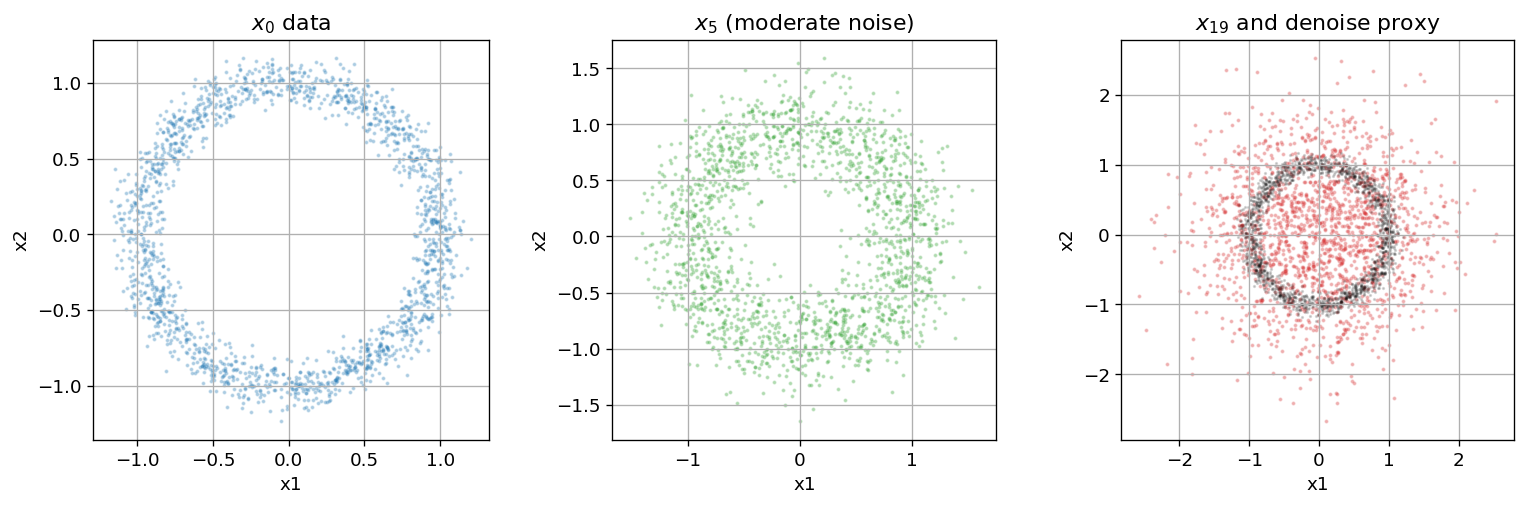

In [2]:
N = 1800
theta = rng.uniform(0, 2*np.pi, size=N)
r = 1.0 + 0.08*rng.normal(size=N)
x0 = np.c_[r*np.cos(theta), r*np.sin(theta)]

T = 20
beta = np.linspace(0.001, 0.05, T)
alpha = 1 - beta
abar = np.cumprod(alpha)

def forward_sample(x, t):
    e = rng.normal(size=x.shape)
    return np.sqrt(abar[t]) * x + np.sqrt(1 - abar[t]) * e

x5 = forward_sample(x0, 5)
x19 = forward_sample(x0, 19)

# Simple denoise proxy using known x0 relation for didactic visualization.
e_hat = (x19 - np.sqrt(abar[19]) * x0) / np.sqrt(1 - abar[19] + 1e-12)
x_rec = (x19 - np.sqrt(1 - abar[19]) * e_hat) / np.sqrt(abar[19] + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2))
axes[0].scatter(x0[:, 0], x0[:, 1], s=2, alpha=0.24)
axes[0].set_title(r"$x_0$ data")
axes[1].scatter(x5[:, 0], x5[:, 1], s=2, alpha=0.24, color="tab:green")
axes[1].set_title(r"$x_5$ (moderate noise)")
axes[2].scatter(x19[:, 0], x19[:, 1], s=2, alpha=0.24, color="tab:red")
axes[2].scatter(x_rec[:, 0], x_rec[:, 1], s=1, alpha=0.14, color="k")
axes[2].set_title(r"$x_{19}$ and denoise proxy")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- J. Ho, A. Jain, P. Abbeel, "Denoising Diffusion Probabilistic Models", NeurIPS, 2020.
- Y. Song et al., "Score-Based Generative Modeling through Stochastic Differential Equations", ICLR, 2021.
- Y. Song, S. Ermon, "Generative Modeling by Estimating Gradients of the Data Distribution", NeurIPS, 2019.
